**OpenMM**

In [ ]:
import openmm
print(openmm.__file__)

In [ ]:
from openmm.app import *
from openmm import *
from openmm.unit import kelvin, picosecond, nanometer
from openmm import Platform


pdb = PDBFile('/home/feynman/Downloads/input_pdb/1UBQ.pdb')

forcefield = ForceField('amber19-all.xml', 'amber19/tip3pfb.xml')

modeller = Modeller(pdb.topology, pdb.positions)
modeller.addHydrogens(forcefield)

PDBFile.writeFile(modeller.topology, modeller.positions, open('/home/feynman/Downloads/input_pdb/processed.pdb', 'w'))

system = forcefield.createSystem(modeller.topology, nonbondedMethod=PME,
        nonbondedCutoff=1*nanometer, constraints=HBonds)

integrator = LangevinMiddleIntegrator(300*kelvin, 1/picosecond, 0.004*picosecond)

platform = Platform.getPlatformByName('CUDA')

simulation = Simulation(modeller.topology, system, integrator, platform)

simulation.context.setPositions(modeller.positions)

print("Minimizing...")
simulation.minimizeEnergy()

simulation.reporters.append(DCDReporter('/data/openmm_out/sample/run1/traj.dcd', 1000))

simulation.reporters.append(StateDataReporter('/data/openmm_out/sample/run1/log.txt', 1000, step=True,
        potentialEnergy=True, temperature=True))

simulation.step(100000)
print("Done")

In [ ]:
from openmm.app import *
from openmm import *
from openmm.unit import *

# -----------------------------
# Load minimized structure
# -----------------------------
pdb = PDBFile('minimized.pdb')

# -----------------------------
# Force field
# -----------------------------
forcefield = ForceField(
    'charmm36.xml',
    'implicit/obc2.xml'
)

# -----------------------------
# Build system
# -----------------------------
system = forcefield.createSystem(
    pdb.topology,
    nonbondedMethod=NoCutoff,
    constraints=HBonds
)

# -----------------------------
# Integrator
# -----------------------------
integrator = LangevinIntegrator(
    400*kelvin,
    1/picosecond,
    0.002*picosecond
)

# -----------------------------
# CUDA platform
# -----------------------------
platform = Platform.getPlatformByName('CUDA')

# -----------------------------
# Simulation object
# -----------------------------
simulation = Simulation(
    pdb.topology,
    system,
    integrator,
    platform
)

# -----------------------------
# Set positions
# -----------------------------
simulation.context.setPositions(pdb.positions)

# -----------------------------
# Initialize velocities
# -----------------------------
simulation.context.setVelocitiesToTemperature(
    400*kelvin
)

# -----------------------------
# Reporters
# -----------------------------
simulation.reporters.append(DCDReporter('/data/openmm_out/sample/run1/traj.dcd', 1000))

simulation.reporters.append(StateDataReporter('/data/openmm_out/sample/run1/log.txt', 1000, step=True,
        potentialEnergy=True, kineticEnergy=True, temperature=True, speed=True))

simulation.reporters.append(
    PDBReporter(
        'trajectory.pdb',
        1000
    )
)

# -----------------------------
# Run simulation
# -----------------------------
print("Running equilibration...")

simulation.step(1000000)

print("Done.")

In [ ]:
import mdtraj as md
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------
# Load trajectory
# -----------------------------------

traj = md.load(
    '/data/openmm_out/sample/run1/traj.dcd',
    top='minimized.pdb'
)

print("Trajectory loaded")
print(traj)

# -----------------------------------
# RMSD
# -----------------------------------

rmsd = md.rmsd(
    traj,
    traj,
    0
)

# -----------------------------------
# RMSF
# -----------------------------------

protein_atoms = traj.topology.select("protein and backbone")

traj_superposed = traj.superpose(traj, 0)

rmsf = md.rmsf(
    traj_superposed,
    traj_superposed,
    0,
    atom_indices=protein_atoms
)

# -----------------------------------
# Radius of gyration
# -----------------------------------

rg = md.compute_rg(traj)

# -----------------------------------
# Native contacts Q(t)
# -----------------------------------

native_pairs = traj.topology.select_pairs(
    'protein and name CA',
    'protein and name CA'
)

# Remove nearby sequence neighbors
native_pairs = np.array([
    pair for pair in native_pairs
    if abs(pair[0] - pair[1]) > 3
])

distances = md.compute_distances(
    traj,
    native_pairs
)

native_distances = distances[0]

contact_cutoff = 0.8  # nm

native_contacts = native_distances < contact_cutoff

Q = []

for frame in distances:
    contacts_now = frame < contact_cutoff

    q = np.sum(
        contacts_now & native_contacts
    ) / np.sum(native_contacts)

    Q.append(q)

Q = np.array(Q)

# -----------------------------------
# Plots
# -----------------------------------

fig, axs = plt.subplots(2, 2, figsize=(12,10))

# RMSD
axs[0,0].plot(rmsd)
axs[0,0].set_title("RMSD")
axs[0,0].set_ylabel("nm")

# RMSF
axs[0,1].plot(rmsf)
axs[0,1].set_title("RMSF")
axs[0,1].set_ylabel("nm")

# Radius of gyration
axs[1,0].plot(rg)
axs[1,0].set_title("Radius of Gyration")
axs[1,0].set_ylabel("nm")

# Q(t)
axs[1,1].plot(Q)
axs[1,1].set_title("Native Contacts Q(t)")
axs[1,1].set_ylabel("Q")

plt.tight_layout()
plt.show()

# WT 1PGA 50 ns simulation using CHARMM36m

In [11]:
%autosave 60

from openmm.app import *
from openmm import *
from openmm.unit import *
from sys import stdout

# =========================================================
# LOAD STRUCTURE
# =========================================================

pdb = PDBFile(
    '/home/feynman/Downloads/foldx5_Linux/1PGA_Repair.pdb'
)

# =========================================================
# FORCE FIELD
# =========================================================

forcefield = ForceField(
    'charmm36.xml',
    'implicit/obc2.xml'
)

# =========================================================
# ADD HYDROGENS
# =========================================================

modeller = Modeller(
    pdb.topology,
    pdb.positions
)

modeller.addHydrogens(forcefield)

# =========================================================
# BUILD SYSTEM
# =========================================================

system = forcefield.createSystem(
    modeller.topology,
    nonbondedMethod=NoCutoff,
    constraints=HBonds
)

# =========================================================
# INTEGRATOR
# =========================================================

temperature = 400 * kelvin

integrator = LangevinIntegrator(
    temperature,
    1/picosecond,
    0.002*picosecond
)

# =========================================================
# CUDA PLATFORM
# =========================================================

platform = Platform.getPlatformByName('CUDA')

properties = {
    'CudaPrecision': 'mixed'
}

# =========================================================
# SIMULATION OBJECT
# =========================================================

simulation = Simulation(
    modeller.topology,
    system,
    integrator,
    platform,
    properties
)

# =========================================================
# INITIALIZE POSITIONS + VELOCITIES
# =========================================================

simulation.context.setPositions(modeller.positions)

simulation.context.setVelocitiesToTemperature(
    temperature
)

# =========================================================
# ENERGY MINIMIZATION
# =========================================================

print("Minimizing energy...")

simulation.minimizeEnergy()

print("Minimization complete.")

# =========================================================
# SAVE MINIMIZED STRUCTURE
# =========================================================

positions = simulation.context.getState(
    getPositions=True
).getPositions()

with open('/data/openmm_out/1PGA_mutations/wt_1pga/wt_minimized.pdb', 'w') as f:

    PDBFile.writeFile(
        simulation.topology,
        positions,
        f
    )

print("Saved minimized structure.")

# =========================================================
# EQUILIBRATION
# =========================================================

print("Starting equilibration...")

simulation.step(2500000)

print("Equilibration complete.")

# =========================================================
# REPORTERS
# =========================================================

simulation.reporters.append(
    DCDReporter(
        '/data/openmm_out/1PGA_mutations/wt_1pga/wt_trajectory.dcd',
        5000
    )
)

simulation.reporters.append(
    StateDataReporter(
        '/data/openmm_out/1PGA_mutations/wt_1pga/wt_log.csv',
        5000,
        step=True,
        potentialEnergy=True,
        kineticEnergy=True,
        totalEnergy=True,
        temperature=True,
        speed=True,
        progress=True,
        remainingTime=True,
        totalSteps=25000000,
        separator=','
    )
)

# LIVE OUTPUT INSIDE NOTEBOOK
simulation.reporters.append(
    StateDataReporter(
        stdout,
        5000,
        step=True,
        temperature=True,
        potentialEnergy=True,
        speed=True,
        progress=True,
        remainingTime=True,
        totalSteps=25000000,
        separator=' | '
    )
)

# =========================================================
# PRODUCTION RUN
# =========================================================

print("Starting production run...")

# 50 ns
# timestep = 2 fs
# total steps = 25,000,000

simulation.step(25000000)

print("Production run complete.")

# =========================================================
# SAVE FINAL STRUCTURE
# =========================================================

final_positions = simulation.context.getState(
    getPositions=True
).getPositions()

with open('/data/openmm_out/1PGA_mutations/wt_1pga/wt_final.pdb', 'w') as f:

    PDBFile.writeFile(
        simulation.topology,
        final_positions,
        f
    )

print("Saved final structure.")

Autosaving every 60 seconds
Minimizing energy...
Minimization complete.
Saved minimized structure.
Starting equilibration...
Equilibration complete.
Starting production run...
#"Progress (%)" | "Step" | "Potential Energy (kJ/mole)" | "Temperature (K)" | "Speed (ns/day)" | "Time Remaining"
10.0% | 2505000 | -2440.6095200959858 | 418.66797742369215 | 0 | --
10.0% | 2510000 | -2471.077088063079 | 418.5521775596045 | 2.18e+03 | 29:41
10.1% | 2515000 | -2246.651868959724 | 405.9398400000023 | 2.18e+03 | 29:39
10.1% | 2520000 | -2606.987508701824 | 406.1065735012854 | 2.18e+03 | 29:40
10.1% | 2525000 | -2330.6946208280688 | 403.7607222633058 | 2.18e+03 | 29:41
10.1% | 2530000 | -2221.5566360520033 | 418.7208750289144 | 2.18e+03 | 29:40
10.1% | 2535000 | -2579.9092879425584 | 390.17015972439015 | 2.18e+03 | 29:39
10.2% | 2540000 | -2406.463193055548 | 423.2174517238308 | 2.18e+03 | 29:38
10.2% | 2545000 | -2494.1288485586992 | 393.9838270086392 | 2.18e+03 | 29:37
10.2% | 2550000 | -2104.82451

dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
<mdtraj.Trajectory with 5000 frames, 855 atoms, 56 residues, without unitcells>


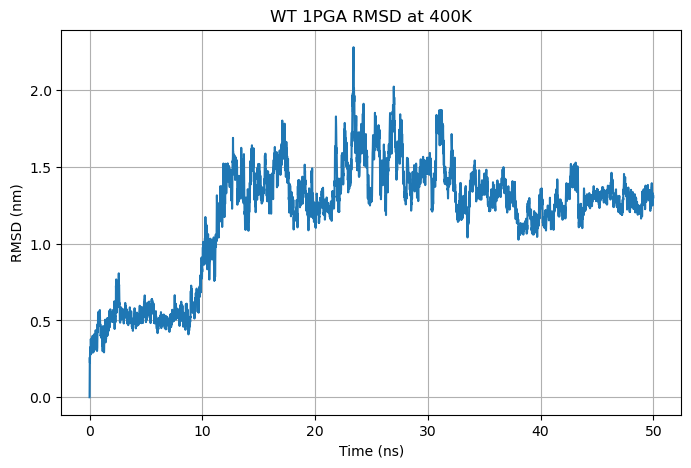

In [33]:
import mdtraj as md
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# LOAD TRAJECTORY
# ============================================

traj = md.load(
    '/data/openmm_out/1PGA_mutations/wt_1pga/wt_trajectory.dcd',
    top='/data/openmm_out/1PGA_mutations/wt_1pga/wt_minimized.pdb'
)

print(traj)

# ============================================
# RMSD CALCULATION
# ============================================

rmsd_wt = md.rmsd(
    traj,
    traj,
    0
)

# ============================================
# TIME AXIS (ns)
# ============================================

time_ns = np.arange(len(traj)) * 0.01

# ============================================
# PLOT
# ============================================

plt.figure(figsize=(8,5))

plt.plot(time_ns, rmsd_wt)

plt.xlabel('Time (ns)')
plt.ylabel('RMSD (nm)')
plt.title('WT 1PGA RMSD at 400K')

plt.grid(True)

plt.show()

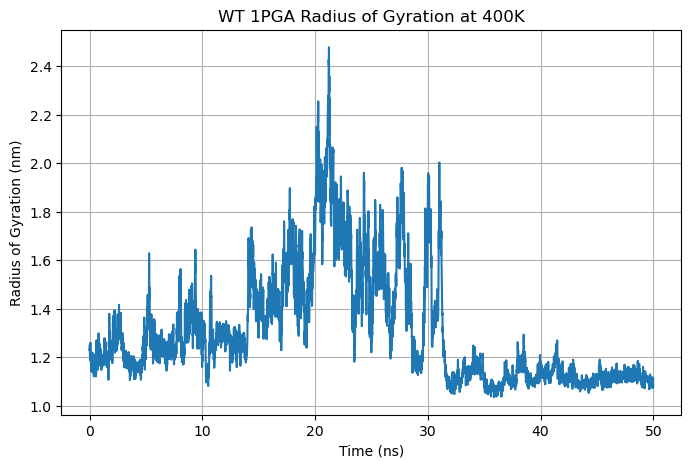

In [35]:
# ============================================
# RADIUS OF GYRATION
# ============================================

rg_wt = md.compute_rg(traj)

plt.figure(figsize=(8,5))

plt.plot(time_ns, rg_wt)

plt.xlabel('Time (ns)')
plt.ylabel('Radius of Gyration (nm)')
plt.title('WT 1PGA Radius of Gyration at 400K')

plt.grid(True)

plt.show()

## Simulate for one mutant (V21P)

In [16]:
%autosave 60

from openmm.app import *
from openmm import *
from openmm.unit import *
from sys import stdout

# =========================================================
# LOAD STRUCTURE
# =========================================================

pdb = PDBFile(
    '/home/feynman/projects/codes/notebooks/mutant_pdbs/V21P.pdb'
)

# =========================================================
# FORCE FIELD
# =========================================================

forcefield = ForceField(
    'charmm36.xml',
    'implicit/obc2.xml'
)

# =========================================================
# ADD HYDROGENS
# =========================================================

modeller = Modeller(
    pdb.topology,
    pdb.positions
)

modeller.addHydrogens(forcefield)

# =========================================================
# BUILD SYSTEM
# =========================================================

system = forcefield.createSystem(
    modeller.topology,
    nonbondedMethod=NoCutoff,
    constraints=HBonds
)

# =========================================================
# INTEGRATOR
# =========================================================

temperature = 400 * kelvin

integrator = LangevinIntegrator(
    temperature,
    1/picosecond,
    0.002*picosecond
)

# =========================================================
# CUDA PLATFORM
# =========================================================

platform = Platform.getPlatformByName('CUDA')

properties = {
    'CudaPrecision': 'mixed'
}

# =========================================================
# SIMULATION OBJECT
# =========================================================

simulation = Simulation(
    modeller.topology,
    system,
    integrator,
    platform,
    properties
)

# =========================================================
# INITIALIZE POSITIONS + VELOCITIES
# =========================================================

simulation.context.setPositions(modeller.positions)

simulation.context.setVelocitiesToTemperature(
    temperature
)

# =========================================================
# ENERGY MINIMIZATION
# =========================================================

print("Minimizing energy...")

simulation.minimizeEnergy()

print("Minimization complete.")

# =========================================================
# SAVE MINIMIZED STRUCTURE
# =========================================================

positions = simulation.context.getState(
    getPositions=True
).getPositions()

with open('/data/openmm_out/1PGA_mutations/V21P/V21P_minimized.pdb', 'w') as f:

    PDBFile.writeFile(
        simulation.topology,
        positions,
        f
    )

print("Saved minimized structure.")

# =========================================================
# EQUILIBRATION
# =========================================================

print("Starting equilibration...")

simulation.step(2500000)

print("Equilibration complete.")

# =========================================================
# REPORTERS
# =========================================================

simulation.reporters.append(
    DCDReporter(
        '/data/openmm_out/1PGA_mutations/V21P/V21P_trajectory.dcd',
        5000
    )
)

simulation.reporters.append(
    StateDataReporter(
        '/data/openmm_out/1PGA_mutations/V21P/V21P_log.csv',
        5000,
        step=True,
        potentialEnergy=True,
        kineticEnergy=True,
        totalEnergy=True,
        temperature=True,
        speed=True,
        progress=True,
        remainingTime=True,
        totalSteps=25000000,
        separator=','
    )
)

# LIVE OUTPUT INSIDE NOTEBOOK
simulation.reporters.append(
    StateDataReporter(
        stdout,
        5000,
        step=True,
        temperature=True,
        potentialEnergy=True,
        speed=True,
        progress=True,
        remainingTime=True,
        totalSteps=25000000,
        separator=' | '
    )
)

# =========================================================
# PRODUCTION RUN
# =========================================================

print("Starting production run...")

# 50 ns
# timestep = 2 fs
# total steps = 25,000,000

simulation.step(25000000)

print("Production run complete.")

# =========================================================
# SAVE FINAL STRUCTURE
# =========================================================

final_positions = simulation.context.getState(
    getPositions=True
).getPositions()

with open('/data/openmm_out/1PGA_mutations/V21P/V21P_final.pdb', 'w') as f:

    PDBFile.writeFile(
        simulation.topology,
        final_positions,
        f
    )

print("Saved final structure.")

Autosaving every 60 seconds
Minimizing energy...
Minimization complete.
Saved minimized structure.
Starting equilibration...
Equilibration complete.
Starting production run...
#"Progress (%)" | "Step" | "Potential Energy (kJ/mole)" | "Temperature (K)" | "Speed (ns/day)" | "Time Remaining"
10.0% | 2505000 | -2208.754231863535 | 412.84382057066506 | 0 | --
10.0% | 2510000 | -2124.636530410684 | 412.56722123671915 | 2.22e+03 | 29:14
10.1% | 2515000 | -2141.6598273393256 | 423.7672926370579 | 2.21e+03 | 29:15
10.1% | 2520000 | -2233.039880983321 | 404.9369869101526 | 2.21e+03 | 29:15
10.1% | 2525000 | -2208.473515618311 | 407.34892581758913 | 2.21e+03 | 29:14
10.1% | 2530000 | -2177.712481144149 | 390.79882860381525 | 2.21e+03 | 29:13
10.1% | 2535000 | -2213.3153974102156 | 386.2847068646233 | 2.22e+03 | 29:11
10.2% | 2540000 | -2143.0126497760575 | 408.0791177762918 | 2.22e+03 | 29:11
10.2% | 2545000 | -2318.025999190512 | 404.15332866355794 | 2.22e+03 | 29:10
10.2% | 2550000 | -2346.5472

dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
<mdtraj.Trajectory with 5000 frames, 853 atoms, 56 residues, without unitcells>


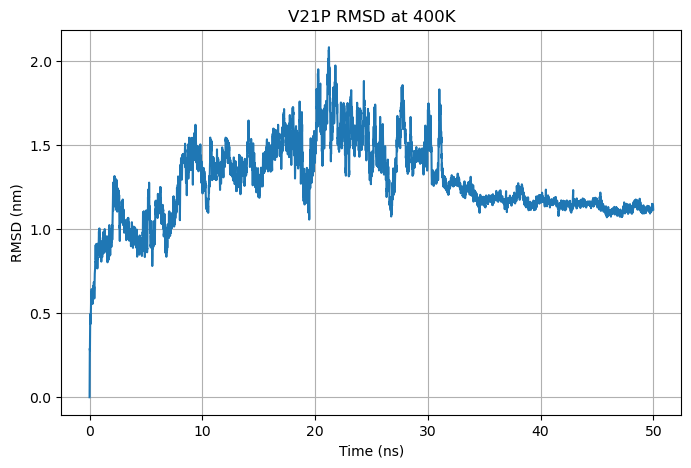

In [34]:
import mdtraj as md
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# LOAD TRAJECTORY
# ============================================

traj = md.load(
    '/data/openmm_out/1PGA_mutations/V21P/V21P_trajectory.dcd',
    top='/data/openmm_out/1PGA_mutations/V21P/V21P_minimized.pdb'
)

print(traj)

# ============================================
# RMSD CALCULATION
# ============================================

rmsd_v21p = md.rmsd(
    traj,
    traj,
    0
)

# ============================================
# TIME AXIS (ns)
# ============================================

time_ns = np.arange(len(traj)) * 0.01

# ============================================
# PLOT
# ============================================

plt.figure(figsize=(8,5))

plt.plot(time_ns, rmsd_v21p)

plt.xlabel('Time (ns)')
plt.ylabel('RMSD (nm)')
plt.title('V21P RMSD at 400K')

plt.grid(True)

plt.show()

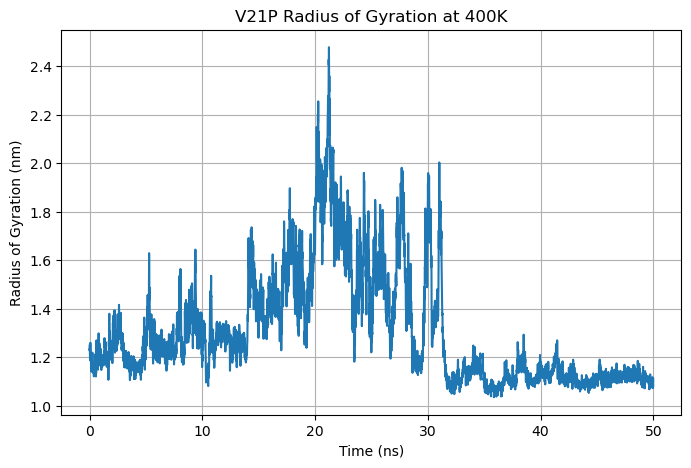

In [36]:
# ============================================
# RADIUS OF GYRATION
# ============================================

rg_v21p = md.compute_rg(traj)

plt.figure(figsize=(8,5))

plt.plot(time_ns, rg_v21p)

plt.xlabel('Time (ns)')
plt.ylabel('Radius of Gyration (nm)')
plt.title('V21P Radius of Gyration at 400K')

plt.grid(True)

plt.show()

dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)


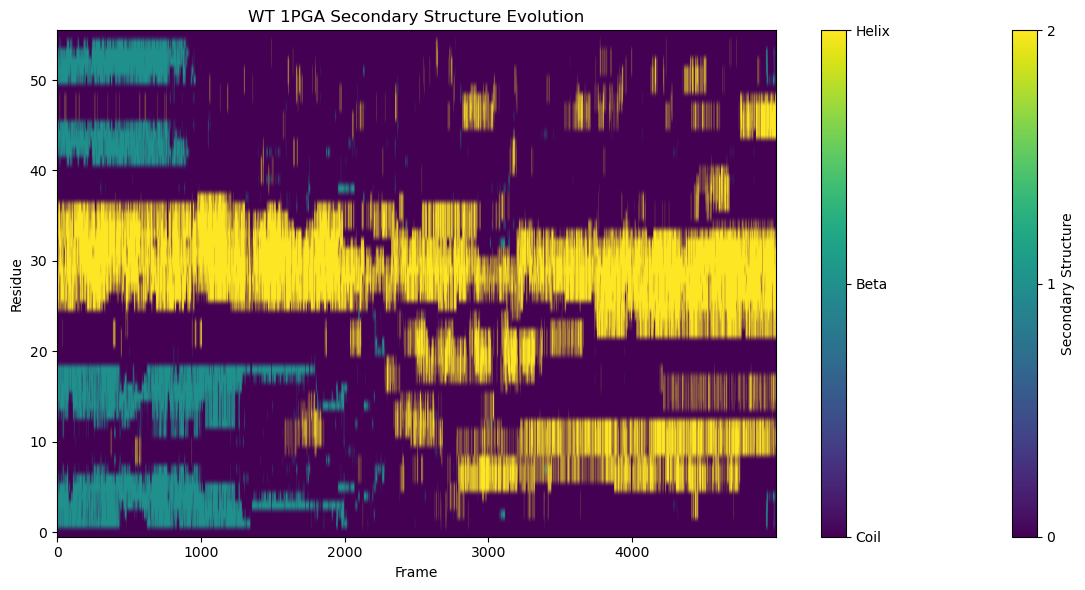

In [23]:
# WT secondary structure plot

import mdtraj as md
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# LOAD TRAJECTORY
# =====================================================

traj = md.load(
    '/data/openmm_out/1PGA_mutations/wt_1pga/wt_trajectory.dcd',
    top='/data/openmm_out/1PGA_mutations/wt_1pga/wt_final.pdb'
)

# =====================================================
# COMPUTE DSSP
# =====================================================

dssp = md.compute_dssp(traj)

# =====================================================
# CONVERT TO NUMERIC
# =====================================================

# H = helix
# E = beta sheet
# C = coil/other

mapping = {
    'H': 2,
    'E': 1
}

numeric_dssp = np.zeros(dssp.shape)

for i in range(dssp.shape[0]):
    for j in range(dssp.shape[1]):

        numeric_dssp[i, j] = mapping.get(
            dssp[i, j],
            0
        )

# =====================================================
# PLOT
# =====================================================

plt.figure(figsize=(12,6))

plt.imshow(
    numeric_dssp.T,
    aspect='auto',
    origin='lower',
    cmap='viridis'
)

plt.colorbar(
    ticks=[0,1,2],
    label='Secondary Structure'
)

plt.clim(0,2)

cbar = plt.colorbar()
cbar.set_ticks([0,1,2])
cbar.set_ticklabels(['Coil','Beta','Helix'])

plt.xlabel('Frame')
plt.ylabel('Residue')

plt.title('WT 1PGA Secondary Structure Evolution')

plt.tight_layout()
plt.show()

dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)


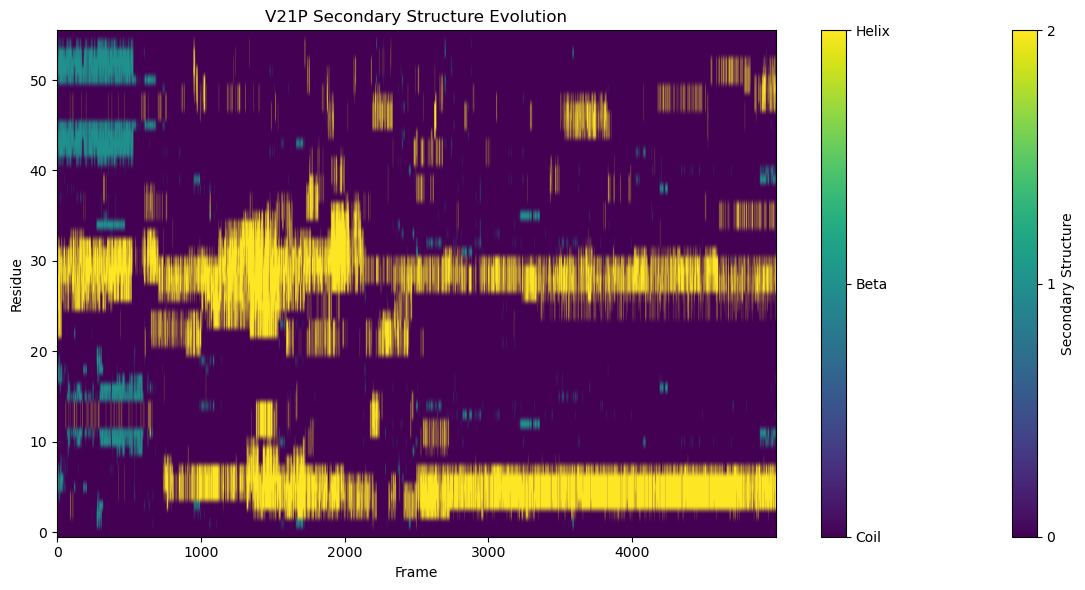

In [25]:
# WT secondary structure plot

import mdtraj as md
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# LOAD TRAJECTORY
# =====================================================

traj = md.load(
    '/data/openmm_out/1PGA_mutations/V21P/V21P_trajectory.dcd',
    top='/data/openmm_out/1PGA_mutations/V21P/V21P_final.pdb'
)

# =====================================================
# COMPUTE DSSP
# =====================================================

dssp = md.compute_dssp(traj)

# =====================================================
# CONVERT TO NUMERIC
# =====================================================

# H = helix
# E = beta sheet
# C = coil/other

mapping = {
    'H': 2,
    'E': 1
}

numeric_dssp = np.zeros(dssp.shape)

for i in range(dssp.shape[0]):
    for j in range(dssp.shape[1]):

        numeric_dssp[i, j] = mapping.get(
            dssp[i, j],
            0
        )

# =====================================================
# PLOT
# =====================================================

plt.figure(figsize=(12,6))

plt.imshow(
    numeric_dssp.T,
    aspect='auto',
    origin='lower',
    cmap='viridis'
)

plt.colorbar(
    ticks=[0,1,2],
    label='Secondary Structure'
)

plt.clim(0,2)

cbar = plt.colorbar()
cbar.set_ticks([0,1,2])
cbar.set_ticklabels(['Coil','Beta','Helix'])

plt.xlabel('Frame')
plt.ylabel('Residue')

plt.title('V21P Secondary Structure Evolution')

plt.tight_layout()
plt.show()

dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)


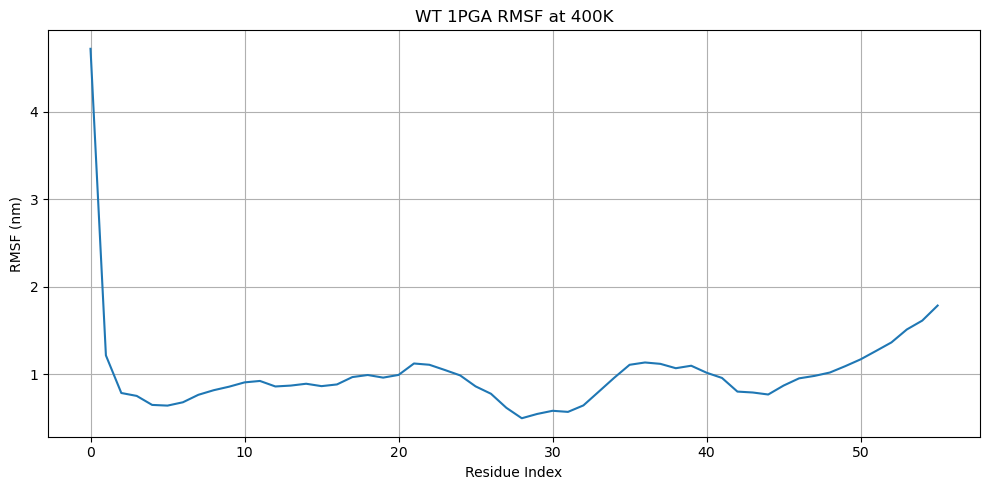

In [26]:
# RMSF plot for WT

import mdtraj as md
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# LOAD WT TRAJECTORY
# =====================================================

traj = md.load(
    '/data/openmm_out/1PGA_mutations/wt_1pga/wt_trajectory.dcd',
    top='/data/openmm_out/1PGA_mutations/wt_1pga/wt_final.pdb'
)

# =====================================================
# ALIGN TRAJECTORY
# =====================================================

traj.superpose(traj[0])

# =====================================================
# SELECT CA ATOMS
# =====================================================

ca_atoms = traj.topology.select('name CA')

# =====================================================
# COMPUTE RMSF
# =====================================================

rmsf = md.rmsf(
    traj,
    traj[0],
    atom_indices=ca_atoms
)

# =====================================================
# PLOT
# =====================================================

plt.figure(figsize=(10,5))

plt.plot(rmsf)

plt.xlabel('Residue Index')
plt.ylabel('RMSF (nm)')

plt.title('WT 1PGA RMSF at 400K')

plt.grid(True)

plt.tight_layout()
plt.show()

dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)


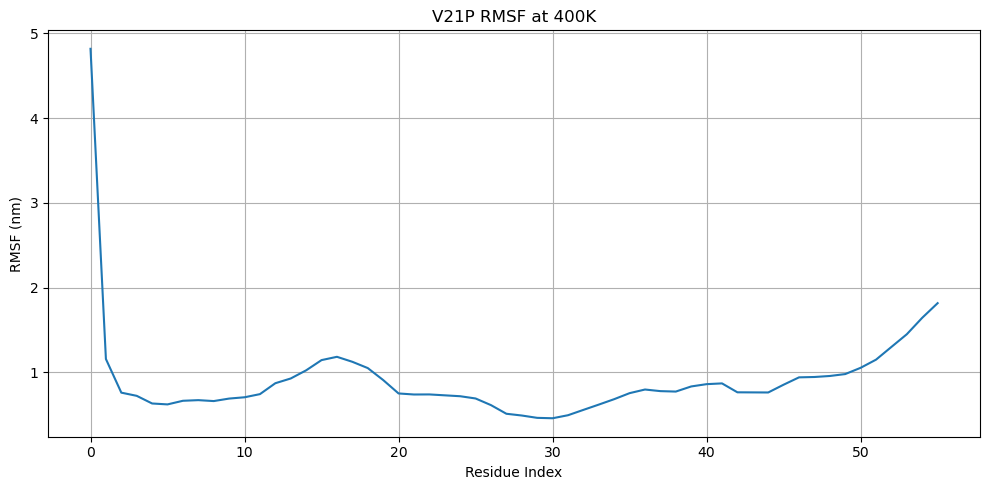

In [27]:
# RMSF plot for V21P

import mdtraj as md
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# LOAD V21P TRAJECTORY
# =====================================================

traj = md.load(
    '/data/openmm_out/1PGA_mutations/V21P/V21P_trajectory.dcd',
    top='/data/openmm_out/1PGA_mutations/V21P/V21P_final.pdb'
)

# =====================================================
# ALIGN TRAJECTORY
# =====================================================

traj.superpose(traj[0])

# =====================================================
# SELECT CA ATOMS
# =====================================================

ca_atoms = traj.topology.select('name CA')

# =====================================================
# COMPUTE RMSF
# =====================================================

rmsf = md.rmsf(
    traj,
    traj[0],
    atom_indices=ca_atoms
)

# =====================================================
# PLOT
# =====================================================

plt.figure(figsize=(10,5))

plt.plot(rmsf)

plt.xlabel('Residue Index')
plt.ylabel('RMSF (nm)')

plt.title('V21P RMSF at 400K')

plt.grid(True)

plt.tight_layout()
plt.show()

dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)


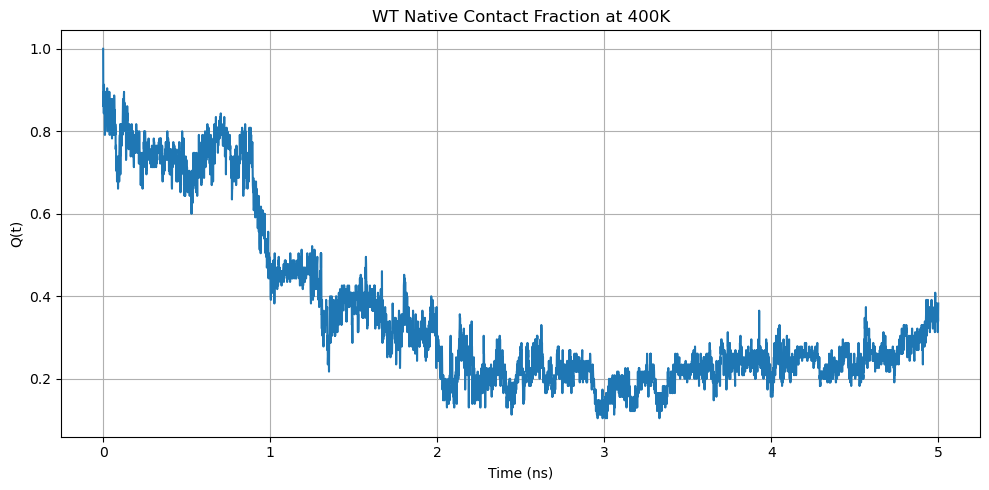

In [29]:
# WT native contact fraction Q(t)

import mdtraj as md
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# LOAD TRAJECTORY
# =====================================================

traj = md.load(
    '/data/openmm_out/1PGA_mutations/wt_1pga/wt_trajectory.dcd',
    top='/data/openmm_out/1PGA_mutations/wt_1pga/wt_final.pdb'
)

# =====================================================
# DEFINE NATIVE STRUCTURE
# =====================================================

native = traj[0]

# =====================================================
# GET NATIVE CONTACTS
# =====================================================

contacts = md.compute_contacts(
    native,
    scheme='ca'
)[0]

pairs = md.compute_contacts(
    native,
    scheme='ca'
)[1]

# =====================================================
# DEFINE NATIVE CONTACTS
# cutoff = 0.8 nm
# =====================================================

native_contacts = pairs[contacts[0] < 0.8]

# =====================================================
# COMPUTE CONTACTS THROUGH TRAJECTORY
# =====================================================

distances, _ = md.compute_contacts(
    traj,
    contacts=native_contacts,
    scheme='ca'
)

# =====================================================
# COMPUTE Q(t)
# =====================================================

Q = np.mean(
    distances < 0.8,
    axis=1
)

# =====================================================
# TIME AXIS
# =====================================================

time_ns = traj.time / 1000

# =====================================================
# PLOT
# =====================================================

plt.figure(figsize=(10,5))

plt.plot(time_ns, Q)

plt.xlabel('Time (ns)')
plt.ylabel('Q(t)')

plt.title('WT Native Contact Fraction at 400K')

plt.grid(True)

plt.tight_layout()
plt.show()

dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)


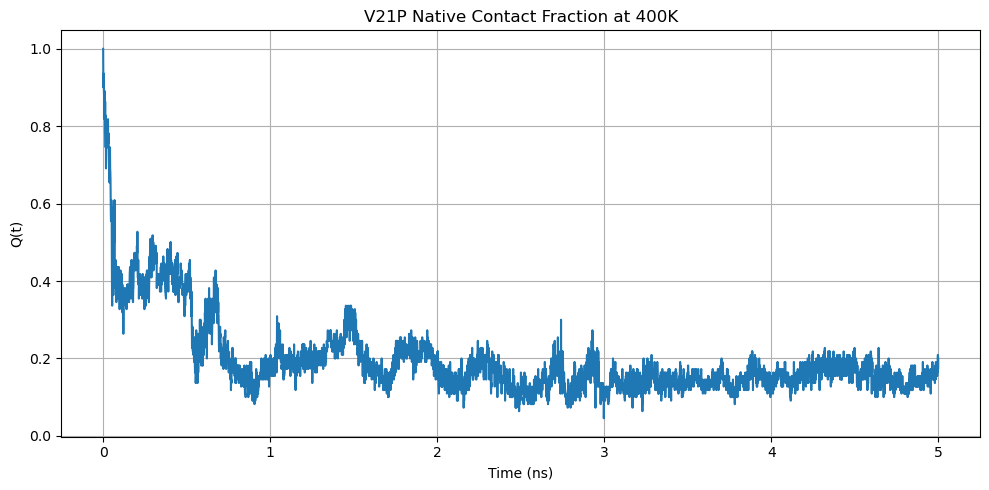

In [30]:
# V21P native contact fraction Q(t)

import mdtraj as md
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# LOAD TRAJECTORY
# =====================================================

traj = md.load(
    '/data/openmm_out/1PGA_mutations/V21P/V21P_trajectory.dcd',
    top='/data/openmm_out/1PGA_mutations/V21P/V21P_final.pdb'
)

# =====================================================
# DEFINE NATIVE STRUCTURE
# =====================================================

native = traj[0]

# =====================================================
# GET NATIVE CONTACTS
# =====================================================

contacts = md.compute_contacts(
    native,
    scheme='ca'
)[0]

pairs = md.compute_contacts(
    native,
    scheme='ca'
)[1]

# =====================================================
# DEFINE NATIVE CONTACTS
# cutoff = 0.8 nm
# =====================================================

native_contacts = pairs[contacts[0] < 0.8]

# =====================================================
# COMPUTE CONTACTS THROUGH TRAJECTORY
# =====================================================

distances, _ = md.compute_contacts(
    traj,
    contacts=native_contacts,
    scheme='ca'
)

# =====================================================
# COMPUTE Q(t)
# =====================================================

Q = np.mean(
    distances < 0.8,
    axis=1
)

# =====================================================
# TIME AXIS
# =====================================================

time_ns = traj.time / 1000

# =====================================================
# PLOT
# =====================================================

plt.figure(figsize=(10,5))

plt.plot(time_ns, Q)

plt.xlabel('Time (ns)')
plt.ylabel('Q(t)')

plt.title('V21P Native Contact Fraction at 400K')

plt.grid(True)

plt.tight_layout()
plt.show()

dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)


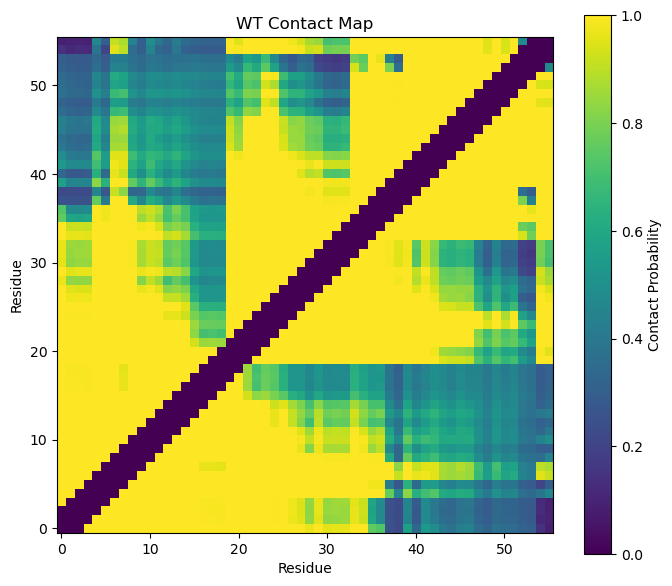

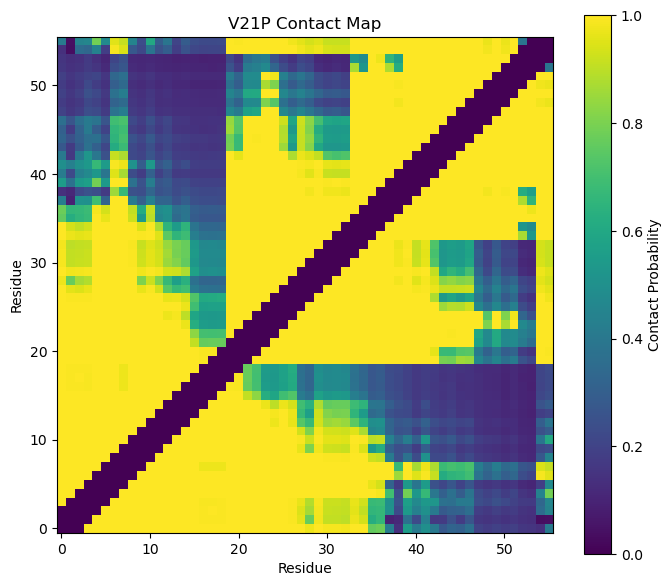

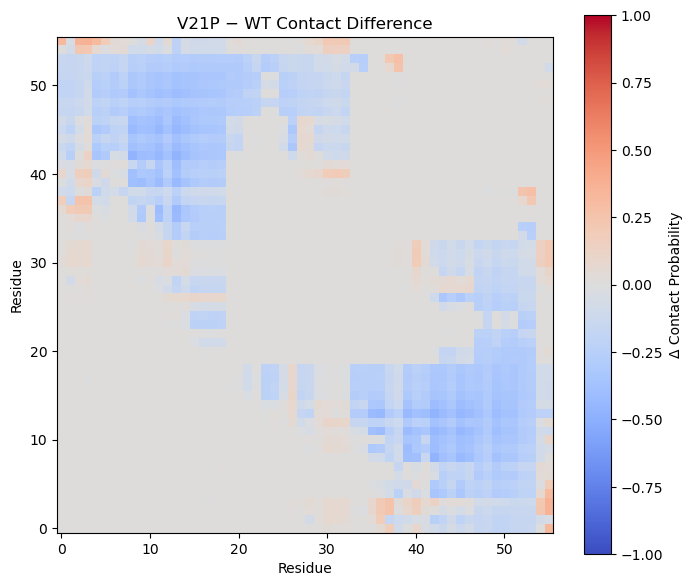

In [31]:
# WT AND V21P CONTACT MAP

import mdtraj as md
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# LOAD TRAJECTORIES
# =========================================================

wt = md.load(
    '/data/openmm_out/1PGA_mutations/wt_1pga/wt_trajectory.dcd',
    top='/data/openmm_out/1PGA_mutations/wt_1pga/wt_final.pdb'
)

mut = md.load(
    '/data/openmm_out/1PGA_mutations/V21P/V21P_trajectory.dcd',
    top='/data/openmm_out/1PGA_mutations/V21P/V21P_final.pdb'
)

# =========================================================
# SELECT CA ATOMS
# =========================================================

wt_ca = wt.topology.select('name CA')
mut_ca = mut.topology.select('name CA')

n_res = len(wt_ca)

# =========================================================
# CREATE RESIDUE PAIRS
# =========================================================

pairs = []

for i in range(n_res):
    for j in range(i+3, n_res):  
        pairs.append([i, j])

pairs = np.array(pairs)

# =========================================================
# COMPUTE DISTANCES
# =========================================================

wt_dist = md.compute_distances(wt, pairs)
mut_dist = md.compute_distances(mut, pairs)

# =========================================================
# DEFINE CONTACTS
# cutoff = 0.8 nm
# =========================================================

cutoff = 0.8

wt_contacts = wt_dist < cutoff
mut_contacts = mut_dist < cutoff

# =========================================================
# CONTACT PROBABILITY MATRICES
# =========================================================

wt_matrix = np.zeros((n_res, n_res))
mut_matrix = np.zeros((n_res, n_res))

for idx, (i, j) in enumerate(pairs):

    wt_prob = np.mean(wt_contacts[:, idx])
    mut_prob = np.mean(mut_contacts[:, idx])

    wt_matrix[i, j] = wt_prob
    wt_matrix[j, i] = wt_prob

    mut_matrix[i, j] = mut_prob
    mut_matrix[j, i] = mut_prob

# =========================================================
# DIFFERENCE MAP
# =========================================================

diff_matrix = mut_matrix - wt_matrix

# =========================================================
# PLOT WT
# =========================================================

plt.figure(figsize=(8,7))

plt.imshow(
    wt_matrix,
    origin='lower',
    cmap='viridis',
    vmin=0,
    vmax=1
)

plt.colorbar(label='Contact Probability')

plt.title('WT Contact Map')
plt.xlabel('Residue')
plt.ylabel('Residue')

plt.show()

# =========================================================
# PLOT MUTANT
# =========================================================

plt.figure(figsize=(8,7))

plt.imshow(
    mut_matrix,
    origin='lower',
    cmap='viridis',
    vmin=0,
    vmax=1
)

plt.colorbar(label='Contact Probability')

plt.title('V21P Contact Map')
plt.xlabel('Residue')
plt.ylabel('Residue')

plt.show()

# =========================================================
# DIFFERENCE MAP
# =========================================================

plt.figure(figsize=(8,7))

plt.imshow(
    diff_matrix,
    origin='lower',
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)

plt.colorbar(label='Δ Contact Probability')

plt.title('V21P − WT Contact Difference')
plt.xlabel('Residue')
plt.ylabel('Residue')

plt.show()

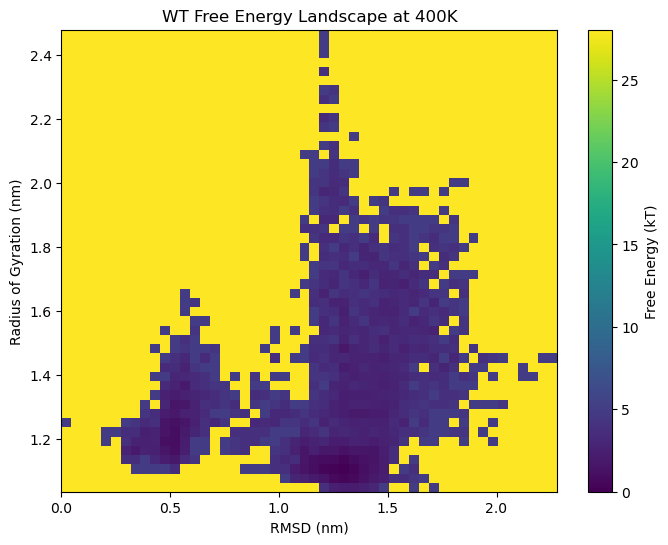

In [38]:
# FREE ENERGY LANDSCAPE for WT

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic_2d

# =========================================================
# LOAD DATA
# =========================================================

# Replace with your arrays
# Example:
# rmsd_wt = ...
# rg_wt = ...

rmsd = rmsd_wt
rg = rg_wt

# =========================================================
# 2D HISTOGRAM
# =========================================================

H, xedges, yedges, binnumber = binned_statistic_2d(
    rmsd,
    rg,
    None,
    statistic='count',
    bins=50
)

# Avoid zeros
H = H + 1e-10

# =========================================================
# FREE ENERGY
# F = -ln(P)
# =========================================================

P = H / np.sum(H)

F = -np.log(P)

# Normalize
F = F - np.min(F)

# =========================================================
# PLOT
# =========================================================

plt.figure(figsize=(8,6))

extent = [
    xedges[0],
    xedges[-1],
    yedges[0],
    yedges[-1]
]

plt.imshow(
    F.T,
    origin='lower',
    extent=extent,
    aspect='auto',
    cmap='viridis'
)

plt.colorbar(label='Free Energy (kT)')

plt.xlabel('RMSD (nm)')
plt.ylabel('Radius of Gyration (nm)')

plt.title('WT Free Energy Landscape at 400K')

plt.show()

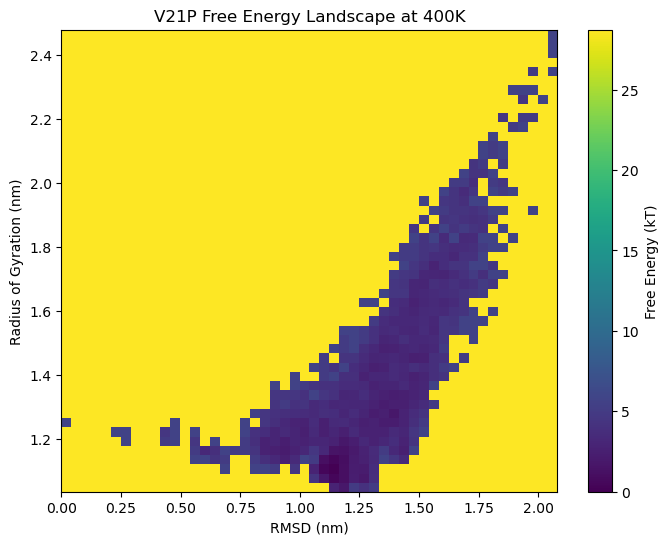

In [ ]:
# FREE ENERGY LANDSCAPE for V21P

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic_2d

# =========================================================
# LOAD DATA
# =========================================================

# Replace with your arrays
# Example:
# rmsd_wt = ...
# rg_wt = ...

rmsd = rmsd_v21p
rg = rg_v21p

# =========================================================
# 2D HISTOGRAM
# =========================================================

H, xedges, yedges, binnumber = binned_statistic_2d(
    rmsd,
    rg,
    None,
    statistic='count',
    bins=50
)

# Avoid zeros
H = H + 1e-10

# =========================================================
# FREE ENERGY
# F = -ln(P)
# =========================================================https://chemistry.du.ac.in/pvenkatesu/#

P = H / np.sum(H)

F = -np.log(P)

# Normalize
F = F - np.min(F)

# =========================================================
# PLOT
# =========================================================

plt.figure(figsize=(8,6))

extent = [
    xedges[0],
    xedges[-1],
    yedges[0],
    yedges[-1]
]

plt.imshow(
    F.T,
    origin='lower',
    extent=extent,
    aspect='auto',
    cmap='viridis'
)

plt.colorbar(label='Free Energy (kT)')

plt.xlabel('RMSD (nm)')
plt.ylabel('Radius of Gyration (nm)')

plt.title('V21P Free Energy Landscape at 400K')

plt.show()